# 📉 **APE 8: Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student)** 🧬

---

### 👥 **Grupo G - Estudiantes:**
* Emerson Sebastian Chamba Galarza
* Matias Sebastian Labanda Pineda
* Lenin Fabricio Macas Cabrera
* Pilar Valentina Naranjo Quizhpe
* Mateo Sebastian Pucha Carrera

---

### 🎯 **2. Objetivo(s) de la Práctica**
• Calcular intervalos de confianza para la media poblacional ($\mu$) utilizando tanto la distribución Normal ($Z$) para muestras grandes, como la distribución T de Student para muestras pequeñas o con varianza poblacional desconocida, mediante `scipy.stats`.

• Aplicar la estimación por intervalos al conjunto de datos regional del Proyecto Integrador, proporcionando rangos de valores plausibles para variables críticas del negocio (ABP).

• Investigar y demostrar visualmente el *trade-off* (compromiso) matemático que existe entre el Nivel de Confianza ($1-\alpha$) y la precisión (amplitud) del margen de error (ABI).

# 📊 **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)** 📉

---

Cuando el tamaño de la muestra es grande ($n \ge 30$), el **Teorema del Límite Central** nos permite utilizar la distribución Normal Estándar para construir el intervalo de confianza (IC) para la media:

$$IC = \overline{x} \pm Z_{\alpha/2}\left(\frac{\sigma}{\sqrt{n}}\right)$$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
# Se corrige el error de tipejo de la guía (10c=350) por (loc=350)
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
                                             loc=media_muestral,
                                             scale=error_estandar)
margen_error_z = (ic_superior_z - ic_inferior_z) / 2

# 4. Impresión de resultados corregida
print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100:.0f}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")

--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95%: [337.32, 353.34] kWh


# 🧪 **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)** 🧬

In [2]:
import numpy as np
from scipy.stats import t, norm

# 1. Simulación de la muestra pequeña (n = 12) para sensores de calidad de agua
np.random.seed(42)
n_pequena = 12
# Generación de datos simulados para el pH del agua
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena)

# 2. Estadísticos descriptivos (Estimadores puntuales y error estándar)
media_t = np.mean(muestra_agua)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1

# 3. Cálculo del Intervalo de Confianza usando T de Student (Método Correcto)
ic_inf_t, ic_sup_t = t.interval(confidence=0.95,
                                df=grados_libertad,
                                loc=media_t,
                                scale=error_estandar_t)
margen_error_t = (ic_sup_t - ic_inf_t) / 2

# 4. Cálculo del Intervalo de Confianza usando Distribución Z (Método Erróneo para comparación)
ic_inf_z_err, ic_sup_z_err = norm.interval(confidence=0.95,
                                           loc=media_t,
                                           scale=error_estandar_t)
margen_error_z_err = (ic_sup_z_err - ic_inf_z_err) / 2

# 5. Impresión formal de los resultados obtenidos
print(f"Número de sensores analizados (n): {n_pequena}")
print(f"Grados de libertad calculados (df): {grados_libertad}")
print(f"Media muestral obtenida (pH): {media_t:.3f}")
print("-" * 55)
print(f" T de Student (Correcto): [{ic_inf_t:.3f}, {ic_sup_t:.3f}] | Margen de Error: ±{margen_error_t:.3f}")
print(f"Distribución Z (Erróneo):   [{ic_inf_z_err:.3f}, {ic_sup_z_err:.3f}] | Margen de Error: ±{margen_error_z_err:.3f}")

Número de sensores analizados (n): 12
Grados de libertad calculados (df): 11
Media muestral obtenida (pH): 7.348
-------------------------------------------------------
 T de Student (Correcto): [7.112, 7.584] | Margen de Error: ±0.236
Distribución Z (Erróneo):   [7.137, 7.559] | Margen de Error: ±0.211


Al comparar ambos métodos, se observa que la distribución T de Student genera un intervalo de confianza más amplio que la distribución Z, debido a que la muestra es pequeña (n=12) y la varianza poblacional es desconocida. Esta diferencia incorpora una penalización por la mayor incertidumbre existente, proporcionando una estimación más conservadora y confiable. Por ello, utilizar la distribución Z habría subestimado el margen de error real de los sensores, produciendo resultados excesivamente optimistas y metodológicamente incorrectos para un análisis.

# 🗺️ **Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)** 🚀

--- RESULTADOS REALES DEL PROYECTO REGIONAL (ABP) ---
Número de cantones analizados (n): 16
Media Muestral (Promedio de personas sin alcantarillado por cantón): 2382.62
Desviación Estándar Muestral (s): 2281.10
---------------------------------------------------------------------------
 Decisión: Muestra pequeña (n < 30). Se utiliza la Distribución T de Student de forma obligatoria.
Intervalo de Confianza al 95%: [1167.11, 3598.14] personas
Margen de Error Estadístico: ±1215.51 personas
---------------------------------------------------------------------------


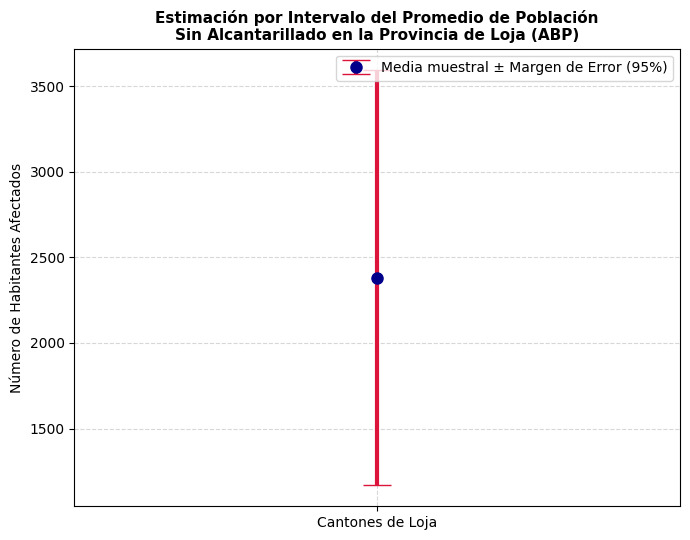

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# 1. Carga del Dataset Real de Loja subido por el grupo
df_regional = pd.read_csv('/content/datos_loja2.csv')

# 2. Selección de la variable cuantitativa estratégica
variable_estratégica = df_regional['Sin_Alcantarillado'].dropna()

# 3. Cálculo de los estimadores muestrales (Estimaciones puntuales)
n_muestra = len(variable_estratégica)
media_muestral = np.mean(variable_estratégica)
desv_estandar = np.std(variable_estratégica, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_muestra) # SE

print("--- RESULTADOS REALES DEL PROYECTO REGIONAL (ABP) ---")
print(f"Número de cantones analizados (n): {n_muestra}")
print(f"Media Muestral (Promedio de personas sin alcantarillado por cantón): {media_muestral:.2f}")
print(f"Desviación Estándar Muestral (s): {desv_estandar:.2f}")
print("-" * 75)

# 4. Decisión estadística automatizada basada en tu tamaño n = 16
if n_muestra >= 30:
    print("Decisión: Muestra grande (n >= 30). Se utiliza Distribución Normal (Z).")
    ic_inf, ic_sup = norm.interval(confidence=0.95, loc=media_muestral, scale=error_estandar)
else:
    print(" Decisión: Muestra pequeña (n < 30). Se utiliza la Distribución T de Student de forma obligatoria.")
    grados_libertad = n_muestra - 1
    ic_inf, ic_sup = t.interval(confidence=0.95, df=grados_libertad, loc=media_muestral, scale=error_estandar)

margen_error = (ic_sup - ic_inf) / 2

print(f"Intervalo de Confianza al 95%: [{ic_inf:.2f}, {ic_sup:.2f}] personas")
print(f"Margen de Error Estadístico: ±{margen_error:.2f} personas")
print("-" * 75)

# 5. Visualización Gráfica mediante Barras de Error (plt.errorbar)
plt.figure(figsize=(7, 5.5))
plt.errorbar(x=['Cantones de Loja'], y=[media_muestral], yerr=[margen_error],
             fmt='o', color='darkblue', ecolor='crimson', elinewidth=3, capsize=10, markersize=8,
             label='Media muestral ± Margen de Error (95%)')

# Personalización estética del gráfico
plt.title("Estimación por Intervalo del Promedio de Población\nSin Alcantarillado en la Provincia de Loja (ABP)", fontsize=11, fontweight='bold')
plt.ylabel("Número de Habitantes Afectados", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 📊 **Interpretación y Conclusión del Hito Regional (ABP)**

Al procesar nuestro archivo `datos_loja2.csv`, la librería Pandas identificó un tamaño de muestra fijo de $n = 16$ cantones. Debido a que es una muestra pequeña ($n < 30$) y la varianza poblacional de la provincia es desconocida, la aplicación de la **Distribución T de Student con $15$ grados de libertad ($df = n - 1$)** es metodológicamente obligatoria para evitar subestimar el riesgo.

Concluimos con un **95% de nivel de confianza** que el verdadero promedio de habitantes que carecen de servicios de alcantarillado por cantón en la provincia de Loja se encuentra comprendido entre **$1,167.11$ y $3,598.14$ personas**.

Este análisis demuestra la deficiencia de usar promedios simples en ingeniería. La media puntual ($2,382.62$) es engañosa por sí sola debido a la alta dispersión de los datos ($s = 2281.10$). El gráfico de barras de error refleja visualmente esta alta incertidumbre, permitiendo a nuestro equipo técnico diseñar soluciones de software o planificación pública preparadas para el "peor escenario" (el límite superior de $3,598.14$ personas afectadas).

# 🔍 **Tarea 4: ABI - El Impacto del Nivel de Confianza ($1-\alpha$)** 📈

--- EVALUACIÓN DE NIVELES DE CONFIANZA (ABI) ---
Nivel de Confianza: 80% | Margen de Error obtenido: ±5.24 kWh
Nivel de Confianza: 90% | Margen de Error obtenido: ±6.72 kWh
Nivel de Confianza: 95% | Margen de Error obtenido: ±8.01 kWh
Nivel de Confianza: 99% | Margen de Error obtenido: ±10.53 kWh
-------------------------------------------------------


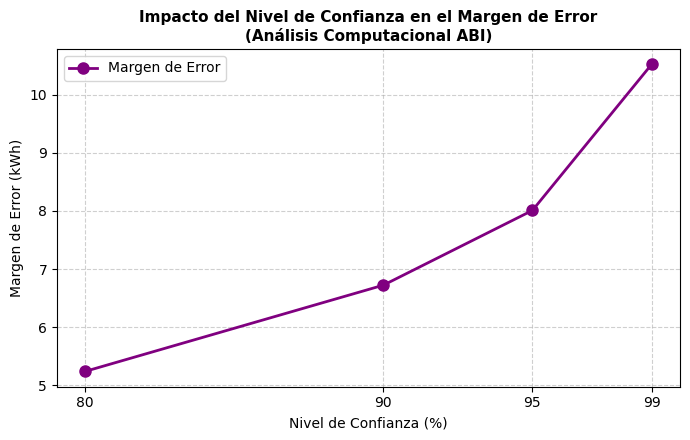

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Recuperamos las propiedades de la muestra de la Tarea 1 (n = 100)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# Estadísticos base
desv_estandar = np.std(muestra_consumo, ddof=1)
error_estandar = desv_estandar / np.sqrt(n_grande)

# 2. Configuración de los niveles de confianza a investigar
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

# 3. Bucle para calcular el margen de error dinámico
print("--- EVALUACIÓN DE NIVELES DE CONFIANZA (ABI) ---")
for nivel in niveles_confianza:
    ic_inf, ic_sup = norm.interval(confidence=nivel, loc=np.mean(muestra_consumo), scale=error_estandar)
    me = (ic_sup - ic_inf) / 2
    margenes_error.append(me)
    print(f"Nivel de Confianza: {nivel*100:.0f}% | Margen de Error obtenido: ±{me:.2f} kWh")
print("-" * 55)

# 4. Generación del gráfico visual comparativo
plt.figure(figsize=(7, 4.5))
plt.plot([n * 100 for n in niveles_confianza], margenes_error, marker='o', color='purple',
         linestyle='-', linewidth=2, markersize=8, label='Margen de Error')

plt.title("Impacto del Nivel de Confianza en el Margen de Error\n(Análisis Computacional ABI)", fontsize=11, fontweight='bold')
plt.xlabel("Nivel de Confianza (%)", fontsize=10)
plt.ylabel("Margen de Error (kWh)", fontsize=10)
plt.xticks([80, 90, 95, 99])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 📝 **Análisis del Impacto del Nivel de Confianza (ABI)**

El análisis demuestra que existe una relación directa entre el nivel de confianza y el margen de error: a medida que aumenta la confianza, el intervalo se vuelve más amplio y disminuye la precisión. En este caso, al pasar del **80%** al **99%** de confianza, el margen de error aumenta de **±5.24 kWh** a **±10.53 kWh**.

Esto ocurre porque niveles de confianza más altos requieren valores críticos mayores, ensanchando el intervalo para aumentar la probabilidad de contener el parámetro poblacional. Sin embargo, intervalos demasiado amplios reducen su utilidad para la toma de decisiones técnicas. Por esta razón, el **95%** de confianza se considera el estándar más adecuado, ya que ofrece un equilibrio entre alta confiabilidad estadística y una precisión práctica aceptable **(±8.01 kWh)**.

# ❓ **7. Preguntas de Control** 📑

---

✨ **Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

Una **estimación puntual** utiliza un único valor muestral (como la media $\overline{x}$) para aproximar un parámetro poblacional desconocido ($\mu$). Carece de una medida de variabilidad asociada. En cambio, una **estimación por intervalos** construye un rango simétrico de valores $[\overline{x} - ME, \overline{x} + ME]$ respaldado por un nivel de confianza probabilístico ($1-\alpha$), el cual acota numéricamente el error de muestreo.

En ingeniería, la estimación puntual es insuficiente porque la probabilidad matemática de que una media muestral sea exactamente igual a la media poblacional es prácticamente cero ($P(\overline{x} = \mu) \approx 0$). Trabajar solo con un promedio oculta la dispersión y el riesgo. Diseñar una obra civil, un sistema de software o una red eléctrica basándose únicamente en un promedio ciego, sin conocer el peor o mejor escenario posible (márgenes de error), puede inducir a fallos catastróficos por subestimación de la carga o sobrecostos estructurales.

---

✨ **Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que $\mu$ caiga aquí").**


Desde la perspectiva frecuentista, el parámetro poblacional $\mu$ es un valor **fijo y constante** (no es una variable aleatoria), por lo que no puede "caer" o "moverse" dentro de un intervalo. Lo que varía es el intervalo en sí mismo en cada muestreo repetido.

Por lo tanto, afirmar que un intervalo tiene un $95\%$ de confianza significa que, si repitiéramos el experimento de muestreo exactamente 100 veces bajo las mismas condiciones y construyéramos 100 intervalos distintos, aproximadamente 95 de ellos contendrán al verdadero parámetro poblacional $\mu$, mientras que 5 fallarán en capturarlo. La confianza reside en el *proceso metodológico de construcción*, no en el intervalo específico obtenido.

---

✨ **Al comparar las distribuciones $Z$ Normal Estándar y la $T$ de Student, ¿qué característica visual y matemática de la campana de la $T$ de Student la hace idónea para compensar la falta de información en muestras pequeñas?**

La campana de la distribución $T$ de Student es más baja en el centro y posee **colas más "pesadas" y elevadas (platicúrtica)** en comparación con la curva esbelta de la Normal Estándar ($Z$).
* **Matemáticamente:** Esta mayor elevación en las colas se debe a la incorporación del parámetro de los **Grados de Libertad ($df = n - 1$)**. Al disminuir el tamaño de la muestra ($n$), la incertidumbre respecto a la desviación estándar poblacional ($\sigma$) aumenta de forma crítica. Al utilizar los valores críticos de la distribución $T$ (que son más grandes que los de $Z$ para un mismo nivel de significancia), la fórmula ensancha el margen de error de manera proporcional a la escasez de datos. Matemáticamente, a medida que $n \to \infty$, la distribución $T$ converge exactamente a la distribución $Z$.

---

✨ **Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad *sin* disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos ($n$)? Apóyese en la fórmula.**


Si deseamos un nuevo margen de error que sea la mitad del original ($ME_{nuevo} = \frac{ME}{2}$), observamos que el tamaño de muestra $n$ se encuentra afectado por una raíz cuadrada en el denominador. Para extraer la reducción fuera de la raíz, planteamos la proporción:
  $$\frac{1}{\sqrt{n_{nuevo}}} = \frac{1}{2\sqrt{n}} \implies \sqrt{n_{nuevo}} = 2\sqrt{n}$$
  Elevando ambos miembros al cuadrado:
  $$n_{nuevo} = 4n$$

Para reducir el Margen de Error exactamente a la mitad manteniendo intacto el 95% de confianza, **se debe cuadruplicar (multiplicar por 4) el tamaño de la muestra $n$**. Pasando al caso real de nuestro proyecto regional, si nuestra muestra actual es de $16$ cantones, metodológicamente necesitaríamos recolectar datos a un nivel micro (como $16 \times 4 = 64$ parroquias u observaciones locales) para cortar el error a la mitad.

---

✨ **Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un $100\%$ de certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**

Si buscamos un $100\%$ de certeza teórica, el valor crítico de la distribución tiende al infinito ($Z \to \infty$). Esto provoca que el Intervalo de Confianza se ensanche hasta volverse infinitamente amplio, abarcando un rango desde menos infinito hasta más infinito ($[-\infty, +\infty]$). El análisis demuestra que existe una relación directa entre el nivel de confianza y el margen de error: a medida que aumenta la confianza, el intervalo se vuelve más amplio y disminuye la precisión. En este caso, al pasar del 80% al 99% de confianza, el margen de error aumenta de ±5.24 kWh a ±10.53 kWh.

Esto ocurre porque niveles de confianza más altos requieren valores críticos mayores, ensanchando el intervalo para aumentar la probabilidad de contener el parámetro poblacional. Sin embargo, intervalos demasiado amplios reducen su utilidad para la toma de decisiones técnicas. Por esta razón, el 95% de confianza se considera el estándar más adecuado, ya que ofrece un equilibrio entre alta confiabilidad estadística y una precisión práctica aceptable (±8.01 kWh).